# Assignment 1 — WhatsApp Chat Analysis

This notebook performs a complete beginner-friendly NLP pipeline on your WhatsApp export.

It includes **text extraction, cleaning, last-6-month filtering, URL/phone/email cleaning, sentence splitting, stopword removal, stemming, lemmatization, sentiment analysis, graphs, and word-cloud images**.

## Privacy note
Senders are anonymized into `Sender_001`, `Sender_002`, etc. Do **not** submit `sender_mapping_private_do_not_submit.csv` unless your professor explicitly asks for real names.

# 2. Import libraries

- `pandas`: table handling
- `re`: regular expressions for parsing and cleaning
- `nltk`: NLP preprocessing and sentiment analysis
- `matplotlib`: graphs
- `wordcloud`: most frequent word image

In [4]:
from pathlib import Path
from datetime import datetime
from collections import Counter
import re
import unicodedata

import pandas as pd
from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

# WordCloud is optional. If installation fails, the rest of the notebook will still work.
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print("wordcloud is not installed. The word cloud cell will be skipped.")

print("Libraries imported successfully.")

Libraries imported successfully.


# 3. Download NLTK resources

NLTK needs small data files for stopwords, lemmatization, and VADER sentiment analysis.

In [5]:
# These downloads require internet one time.
# If they fail, later cells use beginner-friendly fallback lists/functions.

for resource_name in ["stopwords", "wordnet", "omw-1.4", "vader_lexicon"]:
    try:
        nltk.download(resource_name, quiet=True)
        print(f"Checked/downloaded: {resource_name}")
    except Exception as error:
        print(f"Could not download {resource_name}. Fallback code will be used if needed.")
        print(error)

Checked/downloaded: stopwords
Checked/downloaded: wordnet
Checked/downloaded: omw-1.4
Checked/downloaded: vader_lexicon


# 4. Set file paths

Your raw WhatsApp path is already set below.

The notebook also checks fallback paths:

1. Your full Windows path
2. `data/raw/_chat.txt`
3. `_chat.txt`

In [6]:
RAW_CHAT_PATH = Path(r"C:\Users\Vikrant Singh Thakur\OneDrive\Documents\Natural-Language-Processing\Assignments\Assignment 1 - 18th May\data\raw\_chat.txt")

possible_chat_paths = [
    RAW_CHAT_PATH,
    Path("data/raw/_chat.txt"),
    Path("_chat.txt")
]

CHAT_FILE = None

for path in possible_chat_paths:
    if path.exists():
        CHAT_FILE = path
        break

if CHAT_FILE is None:
    raise FileNotFoundError(
        "Could not find _chat.txt. Check the path or place the file in data/raw/_chat.txt."
    )

try:
    ASSIGNMENT_ROOT = CHAT_FILE.parents[2]
    OUTPUT_FOLDER = ASSIGNMENT_ROOT / "outputs" / "chat_analysis"
except IndexError:
    OUTPUT_FOLDER = Path("outputs/chat_analysis")

OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

print("Chat file found at:")
print(CHAT_FILE)
print("\nOutput folder:")
print(OUTPUT_FOLDER)

Chat file found at:
C:\Users\Vikrant Singh Thakur\OneDrive\Documents\Natural-Language-Processing\Assignments\Assignment 1 - 18th May\data\raw\_chat.txt

Output folder:
C:\Users\Vikrant Singh Thakur\OneDrive\Documents\Natural-Language-Processing\Assignments\Assignment 1 - 18th May\outputs\chat_analysis


# 5. Read the raw WhatsApp file

`read_text()` loads the `.txt` file as one large Python string.

In [7]:
raw_text = CHAT_FILE.read_text(encoding="utf-8", errors="replace")

print("Raw chat loaded successfully.")
print("Number of characters in raw chat:", len(raw_text))
print("First 500 characters preview:")
print(raw_text[:500])

Raw chat loaded successfully.
Number of characters in raw chat: 42144
First 500 characters preview:
[07.10.25, 1:44:51 PM] Data Science 2025: ‎Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them.
[07.10.25, 1:44:50 PM] ‎You: ‎‎You created this group
[07.10.25, 1:44:51 PM] Vikrant Singh Thakur: ‎Vikrant Singh Thakur was added
[07.10.25, 1:45:09 PM] ‎You: ‎‎You changed the group name to “Data Science 2025”
[07.10.25, 1:45:19 PM] Martin Bratoi: ‎Martin Bratoi joined using a group link.
[07.10.25, 1:45:37 PM] ~ Shruti Bhandari: ‎~ Shruti Bhandar


# 6. Remove invisible WhatsApp characters

WhatsApp exports often contain invisible Unicode marks. These can break parsing, so we remove them first.

In [8]:
def remove_invisible_characters(text):
    """
    Removes invisible WhatsApp formatting characters.
    """

    invisible_chars = [
        "\u200e", "\u202a", "\u202c", "\u202d", "\u202e",
        "\u2066", "\u2067", "\u2068", "\u2069", "\ufeff"
    ]

    for char in invisible_chars:
        text = text.replace(char, "")

    return text

raw_text = remove_invisible_characters(raw_text)
raw_text = unicodedata.normalize("NFKC", raw_text)

print("Invisible characters removed.")

Invisible characters removed.


# 7. Parse WhatsApp messages into structured rows

A raw WhatsApp line usually looks like:

```text
[07.10.25, 1:44:51 PM] Sender Name: Message text
```

We extract `datetime`, `sender`, and `message`. Multi-line messages are handled too.

In [9]:
message_start_pattern = re.compile(
    r"^\[(\d{1,2}\.\d{1,2}\.\d{2}),\s*"
    r"(\d{1,2}:\d{2}:\d{2})\s*"
    r"([AP]M)?\]\s*"
    r"(.*?):\s*"
    r"(.*)$"
)

records = []
current_record = None

for line in raw_text.splitlines():
    match = message_start_pattern.match(line)

    if match:
        if current_record is not None:
            records.append(current_record)

        date_text = match.group(1)
        time_text = match.group(2)
        am_pm = match.group(3)
        sender = match.group(4).strip()
        message = match.group(5).strip()

        if am_pm:
            message_datetime = datetime.strptime(
                f"{date_text} {time_text} {am_pm}",
                "%d.%m.%y %I:%M:%S %p"
            )
        else:
            message_datetime = datetime.strptime(
                f"{date_text} {time_text}",
                "%d.%m.%y %H:%M:%S"
            )

        current_record = {
            "datetime": message_datetime,
            "sender_original": sender,
            "message_original": message
        }

    else:
        if current_record is not None:
            current_record["message_original"] += "\n" + line.strip()

if current_record is not None:
    records.append(current_record)

df = pd.DataFrame(records)

print("Parsed WhatsApp rows:", len(df))
df.head()

Parsed WhatsApp rows: 394


,datetime,sender_original,message_original
0,2025-10-07 13:44:51,Data Science 2025,Messages and calls are end-to-end encrypted. O...
1,2025-10-07 13:44:50,You,You created this group
2,2025-10-07 13:44:51,Vikrant Singh Thakur,Vikrant Singh Thakur was added
3,2025-10-07 13:45:09,You,You changed the group name to “Data Science 2025”
4,2025-10-07 13:45:19,Martin Bratoi,Martin Bratoi joined using a group link.


# 8. Add date/time columns

These columns make graphing easier.

In [10]:
df["date"] = df["datetime"].dt.date
df["month"] = df["datetime"].dt.to_period("M").astype(str)
df["weekday"] = df["datetime"].dt.day_name()
df["hour"] = df["datetime"].dt.hour

df[["datetime", "date", "month", "weekday", "hour"]].head()

,datetime,date,month,weekday,hour
0,2025-10-07 13:44:51,2025-10-07,2025-10,Tuesday,13
1,2025-10-07 13:44:50,2025-10-07,2025-10,Tuesday,13
2,2025-10-07 13:44:51,2025-10-07,2025-10,Tuesday,13
3,2025-10-07 13:45:09,2025-10-07,2025-10,Tuesday,13
4,2025-10-07 13:45:19,2025-10-07,2025-10,Tuesday,13


# 9. Anonymize senders

Real names and phone numbers are replaced with anonymous IDs.

In [11]:
unique_senders = sorted(df["sender_original"].dropna().unique())

sender_mapping = {
    sender: f"Sender_{number:03d}"
    for number, sender in enumerate(unique_senders, start=1)
}

df["sender"] = df["sender_original"].map(sender_mapping)

sender_mapping_df = pd.DataFrame(
    list(sender_mapping.items()),
    columns=["sender_original", "sender_anonymous"]
)

sender_mapping_df.to_csv(
    OUTPUT_FOLDER / "sender_mapping_private_do_not_submit.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Number of unique senders:", df["sender"].nunique())
df[["sender_original", "sender"]].head()

Number of unique senders: 53


,sender_original,sender
0,Data Science 2025,Sender_033
1,You,Sender_041
2,Vikrant Singh Thakur,Sender_039
3,You,Sender_041
4,Martin Bratoi,Sender_038


# 10. Detect system, media, and deleted messages

These are not useful for NLP sentiment analysis.

In [12]:
system_or_media_pattern = re.compile(
    r"joined using a group link|"
    r"was added|"
    r"\bleft\b|"
    r"created this group|"
    r"changed the group name|"
    r"changed the group description|"
    r"this group has over|"
    r"messages and calls are end-to-end encrypted|"
    r"anyone in this group can invite|"
    r"image omitted|"
    r"video omitted|"
    r"audio omitted|"
    r"document omitted|"
    r"sticker omitted|"
    r"gif omitted|"
    r"media omitted|"
    r"this message was deleted",
    flags=re.IGNORECASE
)

df["is_system_or_media"] = df["message_original"].str.contains(
    system_or_media_pattern,
    na=False
)

print("System/media/deleted rows:", df["is_system_or_media"].sum())
print("Normal user-written rows:", (df["is_system_or_media"] == False).sum())

System/media/deleted rows: 138
Normal user-written rows: 256


# 11. Filter last 6 months

We calculate the last 6 months from the latest message inside the chat export.

In [13]:
latest_message_date = df["datetime"].max()
six_month_cutoff = latest_message_date - relativedelta(months=6)

df_last_6_months = df[df["datetime"] >= six_month_cutoff].copy()

print("First message date:", df["datetime"].min())
print("Latest message date:", latest_message_date)
print("Six-month cutoff date:", six_month_cutoff)
print("Rows after last 6 months filter:", len(df_last_6_months))

First message date: 2025-10-07 13:44:50
Latest message date: 2026-05-11 13:30:57
Six-month cutoff date: 2025-11-11 13:30:57
Rows after last 6 months filter: 175


# 12. Keep only real user messages for NLP

In [14]:
nlp_df = df_last_6_months[
    df_last_6_months["is_system_or_media"] == False
].copy()

print("Rows used for NLP:", len(nlp_df))
nlp_df[["datetime", "sender", "message_original"]].head()

Rows used for NLP: 112


,datetime,sender,message_original
218,2025-11-11 13:41:41,Sender_034,"from Ms. Chandna:\n\nDear all,\nI hope you are..."
219,2025-11-11 14:30:55,Sender_013,+49 15510 860753 added +91 70219 67227
221,2025-11-12 14:17:37,Sender_031,Is anyone is there for the introduction sessi...
222,2025-11-16 10:43:45,Sender_038,"Good morning everyone,\nhere is an event that ..."
224,2025-11-16 21:41:27,Sender_034,For anyone planning to spend the 3rd semester ...


# 13. Extended cleaning

We clean URLs, emails, phone numbers, line breaks, and extra spaces.

For sentiment analysis, we keep negation words like **not** and **don't**, because removing them changes meaning.

In [15]:
url_pattern = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)
email_pattern = re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b")
phone_pattern = re.compile(r"(?:\+?\d[\d\s\-\(\)\u00a0]{7,}\d)")


def clean_private_information(text):
    """Replaces URLs, emails, and phone numbers with placeholders."""

    text = str(text)
    text = unicodedata.normalize("NFKC", text)
    text = url_pattern.sub(" URL ", text)
    text = email_pattern.sub(" EMAIL ", text)
    text = phone_pattern.sub(" PHONE ", text)
    return text


def clean_for_sentiment(text):
    """Cleans text for sentiment while keeping punctuation and negation."""

    text = clean_private_information(text)
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_for_nlp_tokens(text):
    """Cleans text for token analysis."""

    text = clean_private_information(text)
    text = text.lower()
    text = text.replace("\n", " ")
    text = re.sub(r"[^a-zA-Z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


nlp_df["message_for_sentiment"] = nlp_df["message_original"].apply(clean_for_sentiment)
nlp_df["message_clean_nlp"] = nlp_df["message_original"].apply(clean_for_nlp_tokens)

nlp_df[["message_original", "message_for_sentiment", "message_clean_nlp"]].head()

,message_original,message_for_sentiment,message_clean_nlp
218,"from Ms. Chandna:\n\nDear all,\nI hope you are...","from Ms. Chandna: Dear all, I hope you are doi...",from ms chandna dear all i hope you are doing ...
219,+49 15510 860753 added +91 70219 67227,PHONE added PHONE,phone added phone
221,Is anyone is there for the introduction sessi...,Is anyone is there for the introduction session ?,is anyone is there for the introduction session
222,"Good morning everyone,\nhere is an event that ...","Good morning everyone, here is an event that w...",good morning everyone here is an event that wa...
224,For anyone planning to spend the 3rd semester ...,For anyone planning to spend the 3rd semester ...,for anyone planning to spend the rd semester a...


# 14. Split messages into shorter sentences

Long messages are split into shorter sentence-level rows for more precise sentiment analysis.

In [16]:
def split_into_short_sentences(text, max_words=18):
    """Splits one message into shorter sentence-like parts."""

    text = str(text)
    text = text.replace("\n", ". ")
    rough_sentences = re.split(r"(?<=[.!?])\s+", text)
    short_sentences = []

    for sentence in rough_sentences:
        sentence = sentence.strip()
        if not sentence:
            continue

        words = sentence.split()

        if len(words) <= max_words:
            short_sentences.append(sentence)
        else:
            for start_index in range(0, len(words), max_words):
                chunk = words[start_index:start_index + max_words]
                short_sentences.append(" ".join(chunk))

    return short_sentences


nlp_df["short_sentences"] = nlp_df["message_for_sentiment"].apply(split_into_short_sentences)

sentence_df = nlp_df.explode("short_sentences").copy()
sentence_df = sentence_df.rename(columns={"short_sentences": "sentence_original"})

sentence_df["sentence_for_sentiment"] = sentence_df["sentence_original"].apply(clean_for_sentiment)
sentence_df["sentence_clean_nlp"] = sentence_df["sentence_original"].apply(clean_for_nlp_tokens)

print("Original message rows:", len(nlp_df))
print("Sentence-level rows:", len(sentence_df))
sentence_df[["sender", "sentence_original", "sentence_clean_nlp"]].head(10)

Original message rows: 112
Sentence-level rows: 212


,sender,sentence_original,sentence_clean_nlp
218,Sender_034,from Ms.,from ms
218,Sender_034,"Chandna: Dear all, I hope you are doing well.",chandna dear all i hope you are doing well
218,Sender_034,Many of you who have recently arrived have bee...,many of you who have recently arrived have bee...
218,Sender_034,"At the moment, it is difficult for me to sched...",at the moment it is difficult for me to schedu...
218,Sender_034,"Therefore, if you would like to meet, please j...",therefore if you would like to meet please joi...
218,Sender_034,We can use this time to answer your individual...,we can use this time to answer your individual...
218,Sender_034,comfortably settle into the programme.,comfortably settle into the programme
218,Sender_034,"Thank you for your understanding, and I look f...",thank you for your understanding and i look fo...
218,Sender_034,"Kind regards, Prof.",kind regards prof
218,Sender_034,Dr.,dr


# 15. NLP preprocessing

This cell performs:

- **Tokenization**: split text into words
- **Stopword removal**: remove common words like `the`, `and`, `so`, `don't`
- **Stemming**: cut words to rough roots
- **Lemmatization**: convert words to dictionary-like base forms

In [17]:
# Try to load NLTK stopwords.
# If the NLTK resource is missing, use a built-in fallback list.
try:
    english_stopwords = set(stopwords.words("english"))
    print("Using NLTK English stopwords.")
except LookupError:
    print("NLTK stopwords not found. Using fallback stopword list.")
    english_stopwords = {
        "a", "an", "the", "and", "or", "but", "if", "because", "as", "until", "while",
        "of", "at", "by", "for", "with", "about", "against", "between", "into", "through",
        "during", "before", "after", "above", "below", "to", "from", "up", "down", "in",
        "out", "on", "off", "over", "under", "again", "further", "then", "once", "here",
        "there", "when", "where", "why", "how", "all", "any", "both", "each", "few", "more",
        "most", "other", "some", "such", "no", "nor", "not", "only", "own", "same", "so",
        "than", "too", "very", "can", "will", "just", "should", "now", "i", "me", "my", "myself",
        "we", "our", "ours", "ourselves", "you", "your", "yours", "yourself", "yourselves",
        "he", "him", "his", "himself", "she", "her", "hers", "herself", "it", "its", "itself",
        "they", "them", "their", "theirs", "themselves", "what", "which", "who", "whom", "this",
        "that", "these", "those", "am", "is", "are", "was", "were", "be", "been", "being", "have",
        "has", "had", "having", "do", "does", "did", "doing"
    }

custom_stopwords = {
    "dont", "don't", "and", "so", "ok", "okay", "hi", "hello", "hey",
    "guys", "please", "thanks", "thank", "im", "i'm", "u", "ur",
    "anyone", "everyone", "yeah", "yes", "no"
}

all_stopwords = english_stopwords.union(custom_stopwords)

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Check if WordNet lemmatizer data is available.
try:
    _ = lemmatizer.lemmatize("classes")
    WORDNET_AVAILABLE = True
except LookupError:
    WORDNET_AVAILABLE = False
    print("NLTK WordNet not found. Using simple fallback lemmatizer.")


def tokenize_text(text):
    """Splits cleaned text into word tokens."""
    return re.findall(r"[a-zA-Z']+", str(text))


def remove_stopwords_from_tokens(tokens):
    """Removes common words that usually carry little meaning."""

    useful_tokens = []

    for token in tokens:
        token = token.strip().lower()

        if len(token) <= 1:
            continue

        if token in all_stopwords:
            continue

        useful_tokens.append(token)

    return useful_tokens


def stem_tokens(tokens):
    """Applies stemming to every token."""
    return [stemmer.stem(token) for token in tokens]


def simple_fallback_lemmatize(token):
    """
    Very small fallback lemmatizer.
    It is not as powerful as WordNet, but it prevents the notebook from failing.
    """

    if token.endswith("ies") and len(token) > 4:
        return token[:-3] + "y"
    if token.endswith("ses") and len(token) > 4:
        return token[:-2]
    if token.endswith("s") and len(token) > 3:
        return token[:-1]
    return token


def lemmatize_tokens(tokens):
    """Applies lemmatization to every token."""

    if WORDNET_AVAILABLE:
        return [lemmatizer.lemmatize(token) for token in tokens]

    return [simple_fallback_lemmatize(token) for token in tokens]


sentence_df["tokens"] = sentence_df["sentence_clean_nlp"].apply(tokenize_text)
sentence_df["tokens_no_stopwords"] = sentence_df["tokens"].apply(remove_stopwords_from_tokens)
sentence_df["stems"] = sentence_df["tokens_no_stopwords"].apply(stem_tokens)
sentence_df["lemmas"] = sentence_df["tokens_no_stopwords"].apply(lemmatize_tokens)
sentence_df["preprocessed_text"] = sentence_df["lemmas"].apply(lambda tokens: " ".join(tokens))

sentence_df[["sentence_clean_nlp", "tokens", "tokens_no_stopwords", "stems", "lemmas", "preprocessed_text"]].head(10)

Using NLTK English stopwords.


,sentence_clean_nlp,tokens,tokens_no_stopwords,stems,lemmas,preprocessed_text
218,from ms,"[from, ms]",[ms],[ms],[m],m
218,chandna dear all i hope you are doing well,"[chandna, dear, all, i, hope, you, are, doing,...","[chandna, dear, hope, well]","[chandna, dear, hope, well]","[chandna, dear, hope, well]",chandna dear hope well
218,many of you who have recently arrived have bee...,"[many, of, you, who, have, recently, arrived, ...","[many, recently, arrived, reaching, request, i...","[mani, recent, arriv, reach, request, individu...","[many, recently, arrived, reaching, request, i...",many recently arrived reaching request individ...
218,at the moment it is difficult for me to schedu...,"[at, the, moment, it, is, difficult, for, me, ...","[moment, difficult, schedule, separate, meetin...","[moment, difficult, schedul, separ, meet, stud...","[moment, difficult, schedule, separate, meetin...",moment difficult schedule separate meeting stu...
218,therefore if you would like to meet please joi...,"[therefore, if, you, would, like, to, meet, pl...","[therefore, would, like, meet, join, tomorrow,...","[therefor, would, like, meet, join, tomorrow, ...","[therefore, would, like, meet, join, tomorrow,...",therefore would like meet join tomorrow office...
218,we can use this time to answer your individual...,"[we, can, use, this, time, to, answer, your, i...","[use, time, answer, individual, questions, pro...","[use, time, answer, individu, question, provid...","[use, time, answer, individual, question, prov...",use time answer individual question provide sh...
218,comfortably settle into the programme,"[comfortably, settle, into, the, programme]","[comfortably, settle, programme]","[comfort, settl, programm]","[comfortably, settle, programme]",comfortably settle programme
218,thank you for your understanding and i look fo...,"[thank, you, for, your, understanding, and, i,...","[understanding, look, forward, meeting]","[understand, look, forward, meet]","[understanding, look, forward, meeting]",understanding look forward meeting
218,kind regards prof,"[kind, regards, prof]","[kind, regards, prof]","[kind, regard, prof]","[kind, regard, prof]",kind regard prof
218,dr,[dr],[dr],[dr],[dr],dr


# 16. Sentiment analysis with VADER

VADER gives a compound sentiment score from **-1 to +1**.

- `Positive`: score ≥ 0.05
- `Neutral`: between -0.05 and 0.05
- `Negative`: score ≤ -0.05

In [18]:
# Try to use VADER.
# If the VADER lexicon is not available, use a simple fallback lexicon.
try:
    sentiment_analyzer = SentimentIntensityAnalyzer()
    VADER_AVAILABLE = True
    SENTIMENT_METHOD = "VADER sentiment analyzer"
    print("Using VADER sentiment analyzer.")
except LookupError:
    sentiment_analyzer = None
    VADER_AVAILABLE = False
    SENTIMENT_METHOD = "fallback lexicon sentiment analyzer"
    print("VADER lexicon not found. Using fallback sentiment analyzer.")

positive_words = {
    "good", "great", "excellent", "happy", "thanks", "thank", "love", "like", "helpful",
    "nice", "perfect", "awesome", "amazing", "free", "welcome", "congratulations", "best",
    "cool", "success", "successful", "safe", "clear"
}

negative_words = {
    "bad", "worst", "sad", "angry", "problem", "issue", "late", "delay", "delayed",
    "lost", "missing", "confused", "confusing", "wrong", "error", "fail", "failed", "cancelled",
    "canceled", "hard", "difficult", "urgent"
}

negation_words = {"not", "no", "never", "dont", "don't", "cannot", "can't"}


def fallback_sentiment_score(text):
    """
    Simple sentiment fallback.
    Counts positive and negative words.
    Returns a rough score between -1 and +1.
    """

    tokens = tokenize_text(clean_for_nlp_tokens(text))

    if len(tokens) == 0:
        return 0.0

    score = 0

    for token in tokens:
        if token in positive_words:
            score += 1
        elif token in negative_words:
            score -= 1

    # Simple normalization so scores stay small.
    score = score / max(len(tokens), 1)

    # Clip into the -1 to +1 range.
    return max(-1.0, min(1.0, score))


def get_sentiment_score(text):
    """Returns sentiment score."""

    if VADER_AVAILABLE:
        scores = sentiment_analyzer.polarity_scores(str(text))
        return scores["compound"]

    return fallback_sentiment_score(text)


def get_sentiment_label(score):
    """Converts numeric sentiment score into a label."""
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"


sentence_df["sentiment_score"] = sentence_df["sentence_for_sentiment"].apply(get_sentiment_score)
sentence_df["sentiment_label"] = sentence_df["sentiment_score"].apply(get_sentiment_label)

sentence_df[["sentence_for_sentiment", "sentiment_score", "sentiment_label"]].head(15)

Using VADER sentiment analyzer.


,sentence_for_sentiment,sentiment_score,sentiment_label
218,from Ms.,0.0000,Neutral
218,"Chandna: Dear all, I hope you are doing well.",0.7650,Positive
218,Many of you who have recently arrived have bee...,0.2023,Positive
218,"At the moment, it is difficult for me to sched...",-0.3612,Negative
218,"Therefore, if you would like to meet, please j...",0.7184,Positive
218,We can use this time to answer your individual...,0.0000,Neutral
218,comfortably settle into the programme.,0.4215,Positive
218,"Thank you for your understanding, and I look f...",0.3612,Positive
218,"Kind regards, Prof.",0.5267,Positive
218,Dr.,0.0000,Neutral


# 17. Summary tables

In [19]:
summary_table = pd.DataFrame({
    "metric": [
        "Total parsed WhatsApp rows",
        "Date of first parsed message",
        "Date of latest parsed message",
        "Last 6 months cutoff date",
        "Rows after last 6 months filter",
        "Rows used for NLP after removing system/media/deleted messages",
        "Unique senders in full chat",
        "Unique active senders in NLP dataset",
        "Sentence-level rows after splitting",
        "Average sentiment score"
    ],
    "value": [
        len(df),
        df["datetime"].min(),
        df["datetime"].max(),
        six_month_cutoff,
        len(df_last_6_months),
        len(nlp_df),
        df["sender"].nunique(),
        nlp_df["sender"].nunique(),
        len(sentence_df),
        round(sentence_df["sentiment_score"].mean(), 4)
    ]
})

sentiment_summary = sentence_df["sentiment_label"].value_counts().reset_index()
sentiment_summary.columns = ["sentiment_label", "count"]

messages_by_sender = (
    nlp_df.groupby("sender").size().reset_index(name="message_count")
    .sort_values("message_count", ascending=False)
)

messages_by_month = nlp_df.groupby("month").size().reset_index(name="message_count")

messages_by_weekday = (
    nlp_df.groupby("weekday").size().reset_index(name="message_count")
    .sort_values("message_count", ascending=False)
)

messages_by_hour = (
    nlp_df.groupby("hour").size().reset_index(name="message_count")
    .sort_values("hour")
)

summary_table

,metric,value
0,Total parsed WhatsApp rows,394
1,Date of first parsed message,2025-10-07 13:44:50
2,Date of latest parsed message,2026-05-11 13:30:57
3,Last 6 months cutoff date,2025-11-11 13:30:57
4,Rows after last 6 months filter,175
5,Rows used for NLP after removing system/media/...,112
6,Unique senders in full chat,53
7,Unique active senders in NLP dataset,35
8,Sentence-level rows after splitting,212
9,Average sentiment score,0.2086


# 18. Top words and two-word phrases

In [20]:
all_lemmas = []

for token_list in sentence_df["lemmas"]:
    all_lemmas.extend(token_list)

word_counts = Counter(all_lemmas)

top_words = pd.DataFrame(word_counts.most_common(30), columns=["word", "count"])

bigram_list = []

for token_list in sentence_df["lemmas"]:
    for first_word, second_word in zip(token_list, token_list[1:]):
        bigram_list.append(f"{first_word} {second_word}")

bigram_counts = Counter(bigram_list)
top_bigrams = pd.DataFrame(bigram_counts.most_common(30), columns=["bigram", "count"])

print("Top words:")
display(top_words.head(20))

print("Top two-word phrases:")
display(top_bigrams.head(20))

Top words:


,word,count
0,merry,22
1,christmas,22
2,new,16
3,message,13
4,year,13
5,url,11
6,happy,11
7,like,8
8,swati,8
9,phone,8


Top two-word phrases:


,bigram,count
0,merry christmas,22
1,new year,12
2,happy new,11
3,message edited,6
4,would like,4
5,data engineering,4
6,new number,4
7,group start,4
8,good morning,3
9,prof swati,3


# 19. Rule-based topic summary

This counts sentences that match broad assignment-friendly topic categories.

In [21]:
topic_keywords = {
    "Course/Admin/Deadlines": r"\b(?:deadline|report|assignment|exam|semester|class|lecture|schedule|prof|university|document|submission)\b",
    "Social/Events/Greetings": r"\b(?:christmas|new year|merry|happy|party|event|birthday|morning|gather|join)\b",
    "Help/Questions/Logistics": r"\b(?:anyone|where|how|link|find|lost|cable|jacket|registration|office|room|arc|help)\b",
    "Internship/Jobs": r"\b(?:internship|job|career|linkedin|resume|cv)\b",
    "Technical/AI/Data": r"\b(?:ai|data|engineering|science|analysis|process|python|machine|learning|model)\b",
}

topic_rows = []

for topic_name, keyword_pattern in topic_keywords.items():
    count = sentence_df["sentence_clean_nlp"].str.contains(
        keyword_pattern,
        regex=True,
        case=False,
        na=False
    ).sum()

    topic_rows.append({
        "topic": topic_name,
        "matching_sentence_count": count
    })

topic_summary = pd.DataFrame(topic_rows).sort_values(
    "matching_sentence_count",
    ascending=False
)

topic_summary

,topic,matching_sentence_count
1,Social/Events/Greetings,41
2,Help/Questions/Logistics,26
0,Course/Admin/Deadlines,24
4,Technical/AI/Data,21
3,Internship/Jobs,4


# 20. Save output CSV files

In [22]:
df.to_csv(OUTPUT_FOLDER / "01_full_parsed_chat.csv", index=False, encoding="utf-8-sig")
df_last_6_months.to_csv(OUTPUT_FOLDER / "02_last_6_months_all_rows.csv", index=False, encoding="utf-8-sig")
nlp_df.to_csv(OUTPUT_FOLDER / "03_last_6_months_clean_messages.csv", index=False, encoding="utf-8-sig")
sentence_df.to_csv(OUTPUT_FOLDER / "04_sentence_level_preprocessed_sentiment.csv", index=False, encoding="utf-8-sig")
summary_table.to_csv(OUTPUT_FOLDER / "05_summary_table.csv", index=False, encoding="utf-8-sig")
sentiment_summary.to_csv(OUTPUT_FOLDER / "06_sentiment_summary.csv", index=False, encoding="utf-8-sig")
messages_by_sender.to_csv(OUTPUT_FOLDER / "07_messages_by_sender.csv", index=False, encoding="utf-8-sig")
messages_by_month.to_csv(OUTPUT_FOLDER / "08_messages_by_month.csv", index=False, encoding="utf-8-sig")
messages_by_weekday.to_csv(OUTPUT_FOLDER / "09_messages_by_weekday.csv", index=False, encoding="utf-8-sig")
messages_by_hour.to_csv(OUTPUT_FOLDER / "10_messages_by_hour.csv", index=False, encoding="utf-8-sig")
top_words.to_csv(OUTPUT_FOLDER / "11_top_words.csv", index=False, encoding="utf-8-sig")
top_bigrams.to_csv(OUTPUT_FOLDER / "12_top_bigrams.csv", index=False, encoding="utf-8-sig")
topic_summary.to_csv(OUTPUT_FOLDER / "13_topic_summary.csv", index=False, encoding="utf-8-sig")

print("All CSV files saved to:")
print(OUTPUT_FOLDER)

All CSV files saved to:
C:\Users\Vikrant Singh Thakur\OneDrive\Documents\Natural-Language-Processing\Assignments\Assignment 1 - 18th May\outputs\chat_analysis


# 21. Graph — Sentiment distribution

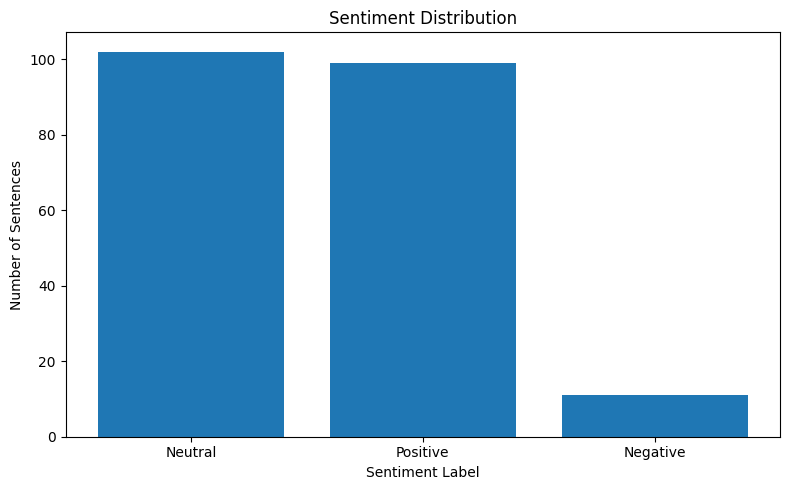

Saved graph: C:\Users\Vikrant Singh Thakur\OneDrive\Documents\Natural-Language-Processing\Assignments\Assignment 1 - 18th May\outputs\chat_analysis\graph_01_sentiment_distribution.png


In [23]:
plt.figure(figsize=(8, 5))
plt.bar(sentiment_summary["sentiment_label"], sentiment_summary["count"])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Number of Sentences")
plt.tight_layout()

sentiment_plot_path = OUTPUT_FOLDER / "graph_01_sentiment_distribution.png"
plt.savefig(sentiment_plot_path, dpi=300)
plt.show()

print("Saved graph:", sentiment_plot_path)

# 22. Graph — Messages by month

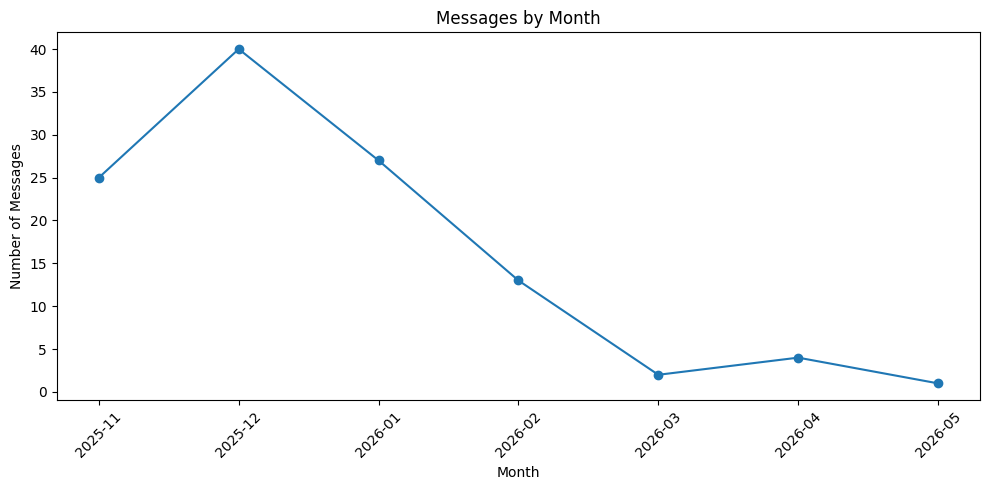

Saved graph: C:\Users\Vikrant Singh Thakur\OneDrive\Documents\Natural-Language-Processing\Assignments\Assignment 1 - 18th May\outputs\chat_analysis\graph_02_messages_by_month.png


In [24]:
plt.figure(figsize=(10, 5))
plt.plot(messages_by_month["month"], messages_by_month["message_count"], marker="o")
plt.title("Messages by Month")
plt.xlabel("Month")
plt.ylabel("Number of Messages")
plt.xticks(rotation=45)
plt.tight_layout()

month_plot_path = OUTPUT_FOLDER / "graph_02_messages_by_month.png"
plt.savefig(month_plot_path, dpi=300)
plt.show()

print("Saved graph:", month_plot_path)

# 23. Graph — Top active senders

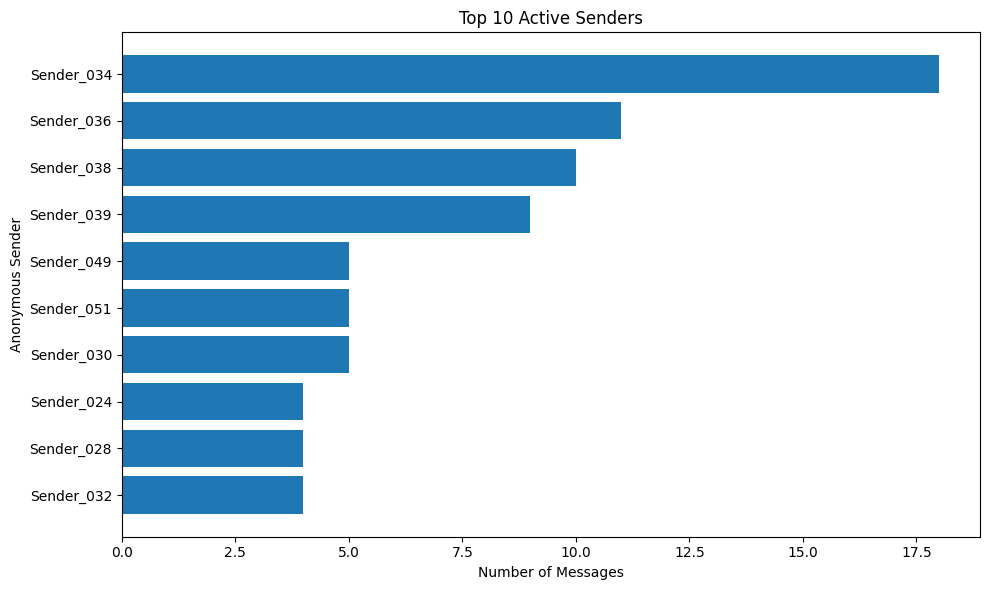

Saved graph: C:\Users\Vikrant Singh Thakur\OneDrive\Documents\Natural-Language-Processing\Assignments\Assignment 1 - 18th May\outputs\chat_analysis\graph_03_top_active_senders.png


In [25]:
top_senders_for_plot = messages_by_sender.head(10).sort_values("message_count")

plt.figure(figsize=(10, 6))
plt.barh(top_senders_for_plot["sender"], top_senders_for_plot["message_count"])
plt.title("Top 10 Active Senders")
plt.xlabel("Number of Messages")
plt.ylabel("Anonymous Sender")
plt.tight_layout()

top_senders_plot_path = OUTPUT_FOLDER / "graph_03_top_active_senders.png"
plt.savefig(top_senders_plot_path, dpi=300)
plt.show()

print("Saved graph:", top_senders_plot_path)

# 24. Graph — Activity by hour

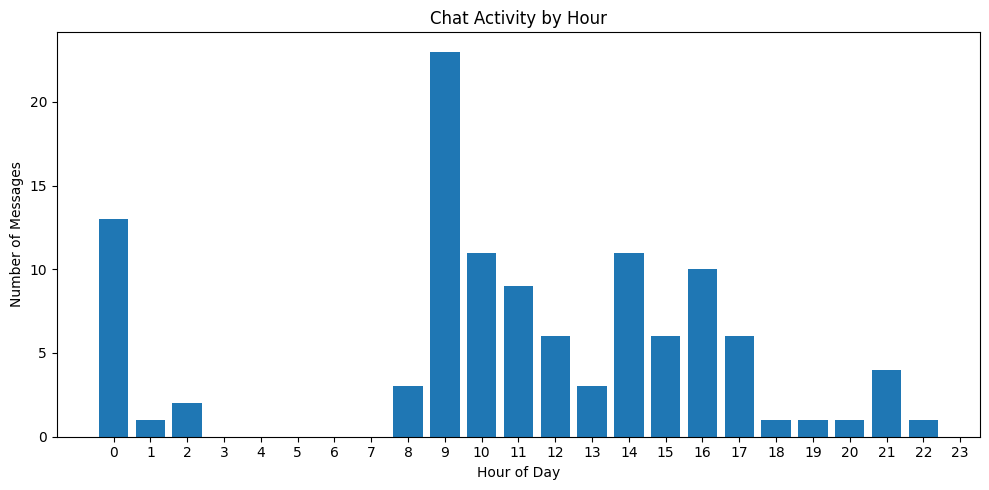

Saved graph: C:\Users\Vikrant Singh Thakur\OneDrive\Documents\Natural-Language-Processing\Assignments\Assignment 1 - 18th May\outputs\chat_analysis\graph_04_activity_by_hour.png


In [26]:
plt.figure(figsize=(10, 5))
plt.bar(messages_by_hour["hour"], messages_by_hour["message_count"])
plt.title("Chat Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Messages")
plt.xticks(range(0, 24))
plt.tight_layout()

hour_plot_path = OUTPUT_FOLDER / "graph_04_activity_by_hour.png"
plt.savefig(hour_plot_path, dpi=300)
plt.show()

print("Saved graph:", hour_plot_path)

# 25. Graph — Top words

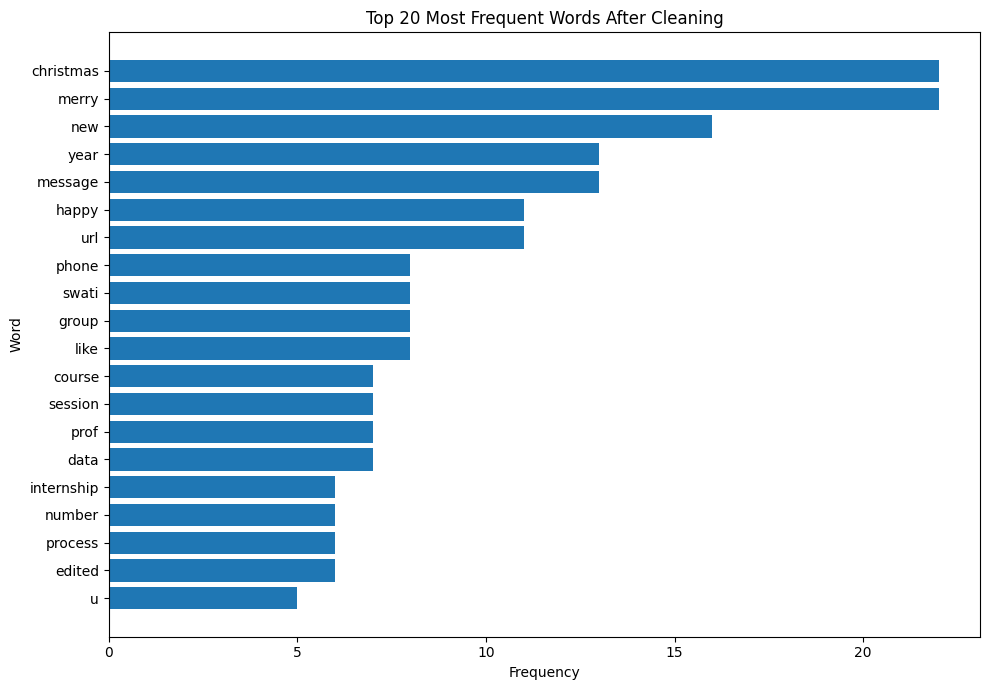

Saved graph: C:\Users\Vikrant Singh Thakur\OneDrive\Documents\Natural-Language-Processing\Assignments\Assignment 1 - 18th May\outputs\chat_analysis\graph_05_top_words.png


In [27]:
top_words_for_plot = top_words.head(20).sort_values("count")

plt.figure(figsize=(10, 7))
plt.barh(top_words_for_plot["word"], top_words_for_plot["count"])
plt.title("Top 20 Most Frequent Words After Cleaning")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()

top_words_plot_path = OUTPUT_FOLDER / "graph_05_top_words.png"
plt.savefig(top_words_plot_path, dpi=300)
plt.show()

print("Saved graph:", top_words_plot_path)

# 26. Cool image — Word cloud of most frequent words

A word cloud makes frequent words appear larger.

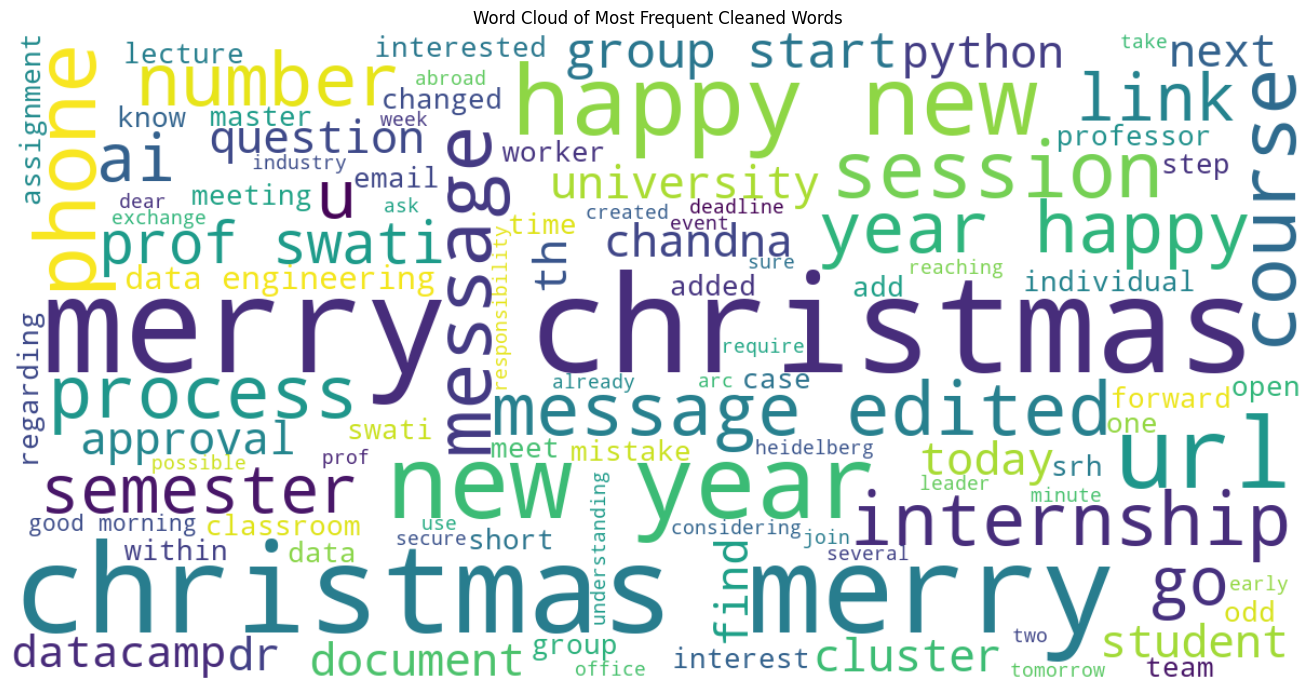

Saved image: C:\Users\Vikrant Singh Thakur\OneDrive\Documents\Natural-Language-Processing\Assignments\Assignment 1 - 18th May\outputs\chat_analysis\image_01_wordcloud_top_words.png


In [28]:
wordcloud_text = " ".join(all_lemmas)

if not WORDCLOUD_AVAILABLE:
    print("wordcloud package is not available. Install it with: pip install wordcloud")
elif len(wordcloud_text.strip()) == 0:
    print("No words available for word cloud.")
else:
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        max_words=100
    ).generate(wordcloud_text)

    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Most Frequent Cleaned Words")
    plt.tight_layout()

    wordcloud_path = OUTPUT_FOLDER / "image_01_wordcloud_top_words.png"
    plt.savefig(wordcloud_path, dpi=300)
    plt.show()

    print("Saved image:", wordcloud_path)

# 27. Cool image — Top two-word phrases

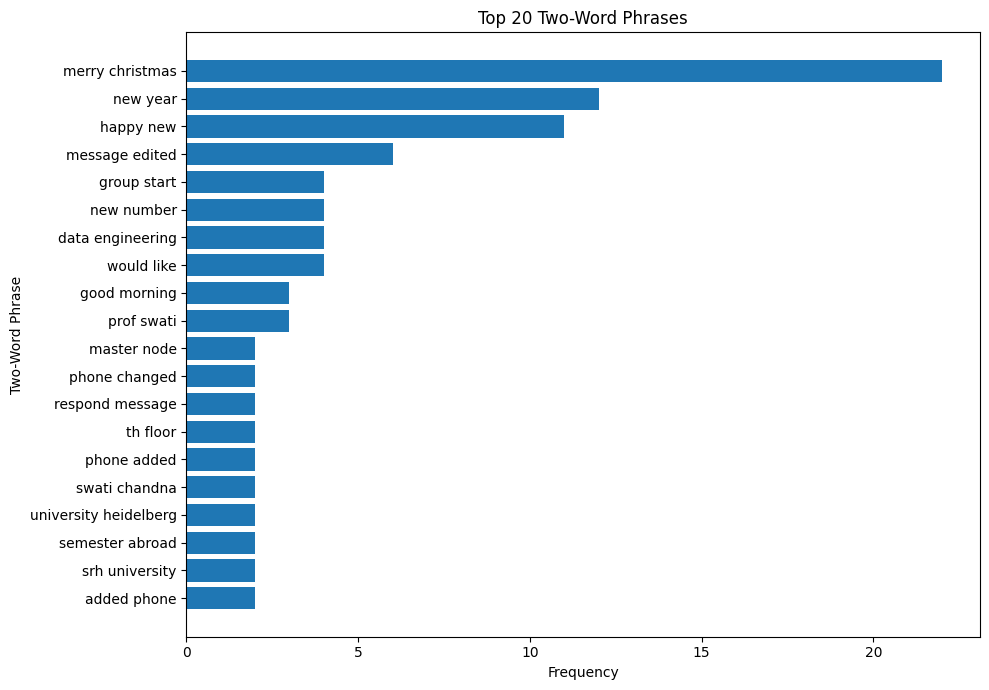

Saved image: C:\Users\Vikrant Singh Thakur\OneDrive\Documents\Natural-Language-Processing\Assignments\Assignment 1 - 18th May\outputs\chat_analysis\image_02_top_two_word_phrases.png


In [29]:
top_bigrams_for_plot = top_bigrams.head(20).sort_values("count")

plt.figure(figsize=(10, 7))
plt.barh(top_bigrams_for_plot["bigram"], top_bigrams_for_plot["count"])
plt.title("Top 20 Two-Word Phrases")
plt.xlabel("Frequency")
plt.ylabel("Two-Word Phrase")
plt.tight_layout()

top_bigrams_plot_path = OUTPUT_FOLDER / "image_02_top_two_word_phrases.png"
plt.savefig(top_bigrams_plot_path, dpi=300)
plt.show()

print("Saved image:", top_bigrams_plot_path)

# 28. Graph — Topic summary

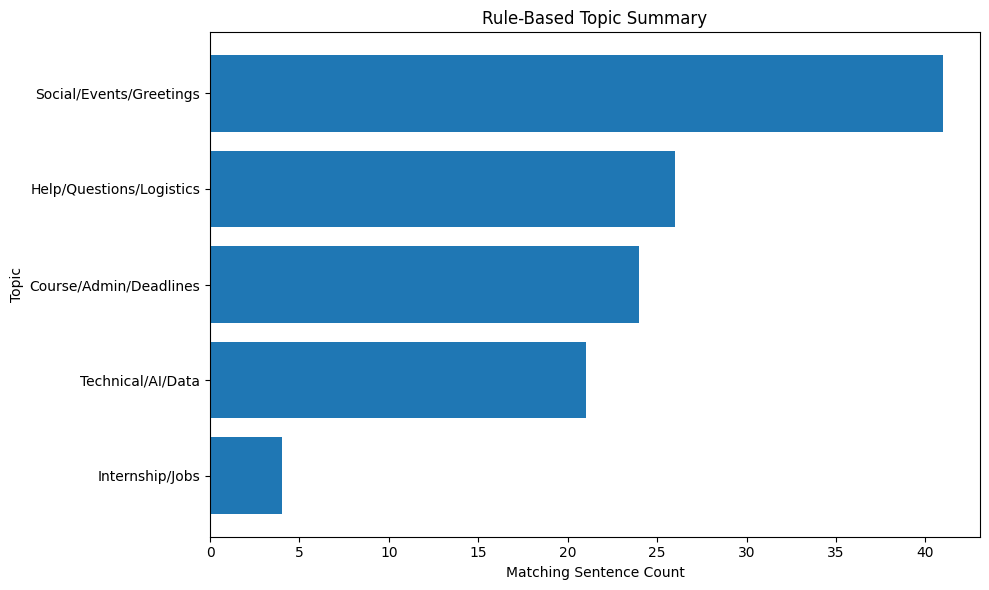

Saved graph: C:\Users\Vikrant Singh Thakur\OneDrive\Documents\Natural-Language-Processing\Assignments\Assignment 1 - 18th May\outputs\chat_analysis\graph_06_topic_summary.png


In [30]:
topic_summary_for_plot = topic_summary.sort_values("matching_sentence_count")

plt.figure(figsize=(10, 6))
plt.barh(topic_summary_for_plot["topic"], topic_summary_for_plot["matching_sentence_count"])
plt.title("Rule-Based Topic Summary")
plt.xlabel("Matching Sentence Count")
plt.ylabel("Topic")
plt.tight_layout()

topic_plot_path = OUTPUT_FOLDER / "graph_06_topic_summary.png"
plt.savefig(topic_plot_path, dpi=300)
plt.show()

print("Saved graph:", topic_plot_path)

# 29. Assignment-ready written summary

Copy this paragraph into your report and adjust after checking your actual graph outputs.

In [31]:
most_common_sentiment = sentiment_summary.sort_values("count", ascending=False).iloc[0]["sentiment_label"]
most_active_hour = messages_by_hour.sort_values("message_count", ascending=False).iloc[0]["hour"]
most_common_word = top_words.iloc[0]["word"] if len(top_words) > 0 else "N/A"
most_common_topic = topic_summary.iloc[0]["topic"] if len(topic_summary) > 0 else "N/A"

report_summary = f"""
Assignment Summary
------------------
The dataset used in this assignment is an exported WhatsApp group chat. The raw text was parsed into structured columns including timestamp, sender, and message. WhatsApp system-generated records such as group join notifications, media placeholders, deleted messages, and other non-user messages were removed before NLP analysis. The analysis was restricted to the last six months of available chat data, using {six_month_cutoff.date()} as the cutoff date.

Extended cleaning was applied to replace URLs, phone numbers, and email addresses with safe placeholders. The messages were then split into shorter sentence-level units. Text preprocessing included lowercasing, tokenization, stopword removal, stemming, and lemmatization. Sentiment analysis was performed using {SENTIMENT_METHOD}. VADER is preferred for short chat-style text, and the notebook contains a fallback method if the VADER lexicon is unavailable.

The final cleaned dataset contains {len(nlp_df)} user-written messages and {len(sentence_df)} sentence-level text units. The dominant sentiment category is {most_common_sentiment}. The most active hour of the day is {most_active_hour}:00. The most frequent cleaned word is '{most_common_word}'. The strongest rule-based topic category is '{most_common_topic}'. Overall, the chat appears to be mainly used for academic coordination, help-seeking, logistics, greetings, and student communication.
"""

print(report_summary)


Assignment Summary
------------------
The dataset used in this assignment is an exported WhatsApp group chat. The raw text was parsed into structured columns including timestamp, sender, and message. WhatsApp system-generated records such as group join notifications, media placeholders, deleted messages, and other non-user messages were removed before NLP analysis. The analysis was restricted to the last six months of available chat data, using 2025-11-11 as the cutoff date.

Extended cleaning was applied to replace URLs, phone numbers, and email addresses with safe placeholders. The messages were then split into shorter sentence-level units. Text preprocessing included lowercasing, tokenization, stopword removal, stemming, and lemmatization. Sentiment analysis was performed using VADER sentiment analyzer. VADER is preferred for short chat-style text, and the notebook contains a fallback method if the VADER lexicon is unavailable.

The final cleaned dataset contains 112 user-written m

# 30. Final checklist

After running the notebook, check:

```text
outputs/chat_analysis/
```

Safe to submit:

- `03_last_6_months_clean_messages.csv`
- `04_sentence_level_preprocessed_sentiment.csv`
- summary CSVs
- graph images
- word cloud image
- this notebook

Do **not** submit unless required:

- `sender_mapping_private_do_not_submit.csv`